<a href="https://colab.research.google.com/github/LucasFaleirosMoreira/university-studies/blob/main/IA_27_09_2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sklearn as sk
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
#importando dataset
dados = sk.datasets.load_breast_cancer()

In [ ]:
dados

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]]),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0

In [ ]:
dados.target_names

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
X, y = dados['target'], dados['target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.5, random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_test.shape, y_train.shape

((500, 4), (500, 4), (500,), (500,))

In [ ]:
clf = RandomForestClassifier(max_depth=2, random_state=0)

In [ ]:
clf.fit(X_train, y_train)

RandomForestClassifier(max_depth=2, random_state=0)

In [ ]:
y_predct = clf.predict_proba(X_test)[:,1]
print(y_predct)

y_predct_train = clf.predict_proba(X_train)[:,1]
print(y_predct_train)

[0.11876729 0.12804608 0.13084385 0.1567706  0.84035924 0.12302335
 0.19456168 0.14947855 0.84848089 0.13637562 0.76100954 0.13573431
 0.14524506 0.8619443  0.84443737 0.83346985 0.84726345 0.81164046
 0.88843444 0.85296651 0.1683849  0.14597558 0.8430064  0.17977609
 0.18697132 0.13546914 0.16119879 0.8475539  0.82334293 0.84760423
 0.84406675 0.1598447  0.12810396 0.85299266 0.81811417 0.13568602
 0.22574308 0.16277737 0.84051804 0.16088432 0.80677761 0.17114677
 0.86712267 0.83023584 0.79596321 0.83052086 0.88433308 0.15849612
 0.8116947  0.83733567 0.15226812 0.84532259 0.38497349 0.12761515
 0.15791371 0.1708513  0.13152607 0.16888884 0.16036852 0.8550291
 0.83418537 0.15702858 0.15105437 0.15119007 0.15849612 0.12572581
 0.16738958 0.87315431 0.15282433 0.17166199 0.12819112 0.83403515
 0.1378768  0.79218818 0.84841762 0.86513927 0.15980621 0.14973832
 0.77759512 0.832385   0.80885716 0.12722688 0.84086679 0.14220697
 0.83326112 0.1478729  0.84182487 0.18612319 0.83695763 0.79551

In [ ]:
y_predct = y_predct > 0.5

y_predct_train = y_predct_train > 0.5

In [ ]:
mc = sk.metrics.confusion_matrix(y_test, y_predct)
tn, fp, fn, tp = mc.ravel()

mc2 = sk.metrics.confusion_matrix(y_train, y_predct_train)
tn2, fp2, fn2, tp2 = mc2.ravel()

In [ ]:
acuracia = accuracy_score(y_test, y_predct)
precisao = precision_score(y_test, y_predct)
recall = recall_score(y_test, y_predct)
f1 = f1_score(y_test, y_predct)
fpr = fp / (fp + tn)
roc = roc_auc_score(y_test, y_predct)
media_precisao = average_precision_score(y_test, y_predct)

acuracia2 = accuracy_score(y_train, y_predct_train)
precisao2 = precision_score(y_train, y_predct_train)
recall2 = recall_score(y_train, y_predct_train)
f12 = f1_score(y_train, y_predct_train)
fpr2 = fp / (fp + tn)
roc2 = roc_auc_score(y_train, y_predct_train)
media_precisao2 = average_precision_score(y_train, y_predct_train)

In [ ]:
print(f"Acuracia: {acuracia*100} \nPrecisão: {precisao*100} \nRecall: {recall*100} \nF1: {f1*100} \nRoc: {roc*100} \nMedia precisão: {media_precisao*100} \nTaxa falso positivo: {fpr*100}")

Acuracia: 93.2 
Precisão: 92.21311475409836 
Recall: 93.75 
F1: 92.97520661157024 
Roc: 93.22115384615385 
Media precisão: 89.44979508196721 
Taxa falso positivo: 7.307692307692308


In [ ]:
print(f"Acuracia2: {acuracia2*100} \nPrecisão2: {precisao2*100} \nRecall2: {recall2*100} \nF12: {f12*100} \nRoc2: {roc2*100} \nMedia precisão2: {media_precisao2*100} \nTaxa falso positivo2: {fpr2*100}")

Acuracia2: 96.2 
Precisão2: 95.05703422053232 
Recall2: 97.65625 
F12: 96.33911368015414 
Roc2: 96.16419057377048 
Media precisão2: 94.02913498098859 
Taxa falso positivo2: [  0.           5.32786885 100.        ]


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_predct)
p_rf, recall_rf, _ = precision_recall_curve(y_test, y_predct)

fpr2, tpr2, thresholds2 = roc_curve(y_train, y_predct_train)
p_rf2, recall_rf2, _ = precision_recall_curve(y_train, y_predct_train)

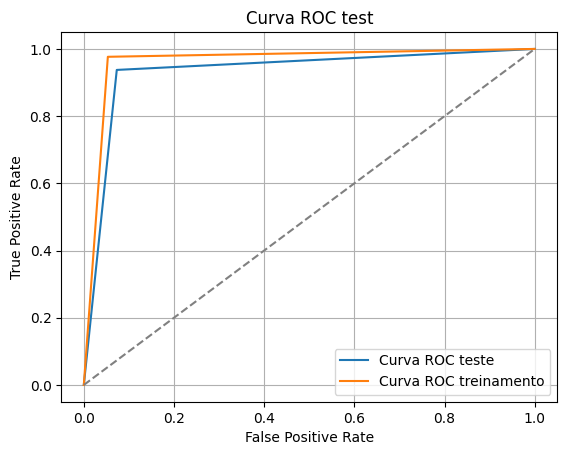

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label='Curva ROC teste')
plt.plot(fpr2, tpr2, label='Curva ROC treinamento')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # linha aleatória
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC test')
plt.legend()
plt.grid()
plt.show()

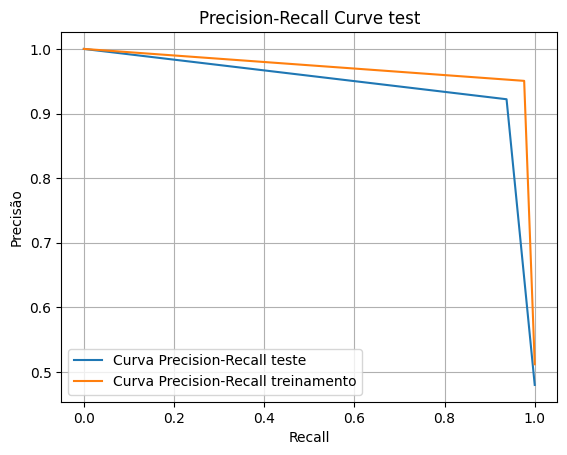

In [ ]:
plt.figure()
plt.plot(recall_rf, p_rf, label='Curva Precision-Recall teste')
plt.plot(recall_rf2, p_rf2, label='Curva Precision-Recall treinamento')
plt.xlabel('Recall')
plt.ylabel('Precisão')
plt.title('Precision-Recall Curve test')
plt.legend()
plt.grid()
plt.show()

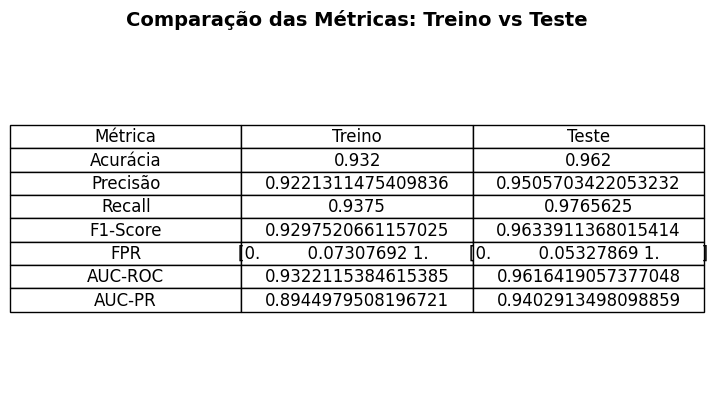

In [ ]:

# Tabela com colunas: Métrica, Treino, Teste
data = [
    ["Acurácia", f"{acuracia}", f"{acuracia2}"],
    ["Precisão", f"{precisao}", f"{precisao2}"],
    ["Recall", f"{recall}", f"{recall2}"],
    ["F1-Score", f"{f1}", f"{f12}"],
    ["FPR", f"{fpr}", f"{fpr2}"],
    ["AUC-ROC", f"{roc}", f"{roc2}"],
    ["AUC-PR", f"{media_precisao}", f"{media_precisao2}"]
]

# Criando a figura
fig, ax = plt.subplots()
ax.axis('off')  # Esconde o gráfico

# Criando a tabela
table = plt.table(
    cellText=data,
    colLabels=["Métrica", "Treino", "Teste"],
    cellLoc='center',
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.4, 1.4)

plt.title("Comparação das Métricas: Treino vs Teste", fontsize=14, fontweight='bold')
plt.show()

**Gabriel Ledolini**


**Lucas Faleiros Moreira**


***Murilo Berti***




1- Sim, houve diferença.


2- O treino teve mais falso positivo e também mais falso negativo


3- Apesar de não ser grande coisa, não, pois o modelo está se dando melhor no teste.


4- Seria necesário mais precisão


5- Talvez mudar o modelo para decisiontree


6- Uma grande diferença não, no maximo na metrica AUC-PR onde tivemos uma diferença de 5%


7- O precisão remete ao total, entao de todos que temos quantos foram realmente positivos, enquanto o recall mostra quantos de todos positivos realmente eram positivos.


8- Priorizar o recall, pois queremos ter certeza que os positivos são realmente positivos


9- ambos estão bem proximos, porem o AUCPRC é mais informativo.
